In [1]:
import torchvision
from torchvision.models import EfficientNet_B2_Weights, efficientnet_b2
from torch import nn
from torch.utils.data import DataLoader
import torch

In [2]:
trans = EfficientNet_B2_Weights.DEFAULT.transforms()
train_DS = torchvision.datasets.CIFAR100("./", True, trans, download=True)
test_DS = torchvision.datasets.CIFAR100("./", False, trans, download=True)

100%|██████████| 169M/169M [06:27<00:00, 436kB/s]


In [6]:
model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT);

In [4]:
model.requires_grad_(False)
model.classifier = nn.Sequential(
    nn.Linear(1408, 256),
    nn.BatchNorm1d(256),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(256, 100)
)
model.features[-5:].requires_grad_(True);

In [7]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [8]:
t_loader = DataLoader(train_DS, 32, True)
v_loader = DataLoader(test_DS, 32, False)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
c_model = torch.compile(model.to(device))

In [10]:
from tqdm.auto import tqdm, trange
ce = nn.CrossEntropyLoss()
EPOCH = 5
T_max = len(t_loader) * EPOCH
t_losses, v_losses = [], []
t_acc, v_acc = [], []
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max)
for epoch in range(EPOCH):
    c_model.train()
    r_t_loss, r_v_loss = 0.0, 0.0
    t_pbar = tqdm(t_loader, leave=False)
    t_true, v_true = 0, 0
    for x_train, y_train in t_pbar:
        x_train, y_train = x_train.to(device), y_train.to(device)
        t_pred = c_model(x_train)
        t_loss = ce(t_pred, y_train)
        opt.zero_grad()
        t_loss.backward()
        opt.step()
        sch.step()
        t_losses.append(t_loss.item())
        r_t_loss += t_loss.item()
        t_pbar.set_postfix(loss=t_loss.item())
        t_true += (t_pred.argmax(-1) == y_train).float().sum()
    c_model.eval()
    with torch.inference_mode():
        v_pbar = tqdm(v_loader, leave=False)
        for x_val, y_val in v_pbar:
            x_val, y_val = x_val.to(device), y_val.to(device)
            v_pred = c_model(x_val)
            v_loss = ce(v_pred, y_val)
            v_pbar.set_postfix(loss=v_loss.item())
            r_v_loss += v_loss.item()
            v_losses.append(v_loss.item())
            v_true += (v_pred.argmax(-1) == y_val).float().sum()
    t_e_acc = t_true / len(t_loader.dataset)
    v_e_acc = v_true / len(v_loader.dataset)
    avg_t_loss = r_t_loss / len(t_loader)
    avg_v_loss = r_v_loss = len(v_loader)
    t_acc.append(t_e_acc)
    v_acc.append(v_e_acc)
    print(f"train loss : {avg_t_loss:.4f} | val loss : {avg_v_loss:.4f}")
    print(f"trian acc : {t_e_acc:.4f} | val acc : {v_e_acc:.4f}")


  0%|          | 0/1563 [00:00<?, ?it/s]

W0930 16:02:28.235000 670 torch/_inductor/utils.py:1436] [0/0] Not enough SMs to use max_autotune_gemm mode


  0%|          | 0/313 [00:00<?, ?it/s]

train loss : 1.8659 | val loss : 313.0000
trian acc : 0.6128 | val acc : 0.8028


  0%|          | 0/1563 [00:00<?, ?it/s]

...

  0%|          | 0/313 [00:00<?, ?it/s]

train loss : 0.3116 | val loss : 313.0000
trian acc : 0.9136 | val acc : 0.8609


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

train loss : 0.2658 | val loss : 313.0000
trian acc : 0.9286 | val acc : 0.8604


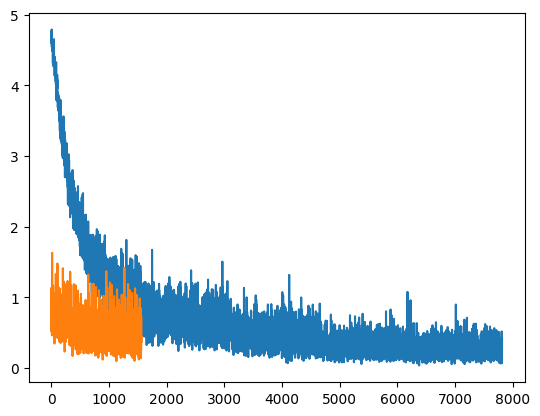

In [11]:
import matplotlib.pyplot as plt
plt.plot(t_losses)
plt.plot(v_losses)